# 03 — Exploratory Data Analysis

Building on the SQL findings (star tier, license, and bus-factor all show 
a relationship with risk), this notebook explores those patterns visually 
and looks for anything SQL's aggregate queries might have missed - 
distributions, outliers, and relationships between numeric signals.

In [4]:
!pip install seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/clean_labeled_repos.csv')
print(df.shape)
df.head()

(498, 25)


,repo,stars,forks,language,license,is_archived,age_days,days_since_last_push,days_since_last_commit,commits_per_month_90d,...,median_issue_resolution_days_recent,open_prs_total,merged_prs_total,median_pr_merge_days_recent,pr_merge_rate_recent,star_tier,has_recent_pr_activity,has_recent_issue_activity,risk_score,risk_category
0,codecrafters-io/build-your-own-x,544722,51316,Markdown,No license,False,3038,49,49.0,1.67,...,0.0,365,157,-1.0,0.00,mega,True,True,0,Low
1,sindresorhus/awesome,502221,36685,None/Not detected,cc0-1.0,False,4435,0,0.0,2.33,...,0.0,89,702,0.0,0.10,mega,True,True,0,Low
2,public-apis/public-apis,474426,52388,Python,mit,False,3817,0,0.0,151.67,...,4.0,1813,2190,1.0,0.32,mega,True,True,0,Low
3,freeCodeCamp/freeCodeCamp,454881,46100,TypeScript,bsd-3-clause,False,4269,0,0.0,269.67,...,0.0,92,29249,0.0,0.42,mega,True,True,0,Low
4,EbookFoundation/free-programming-books,395797,66724,Python,cc-by-4.0,False,4709,1,1.0,20.00,...,2.0,44,7431,1.0,0.46,mega,True,True,0,Low


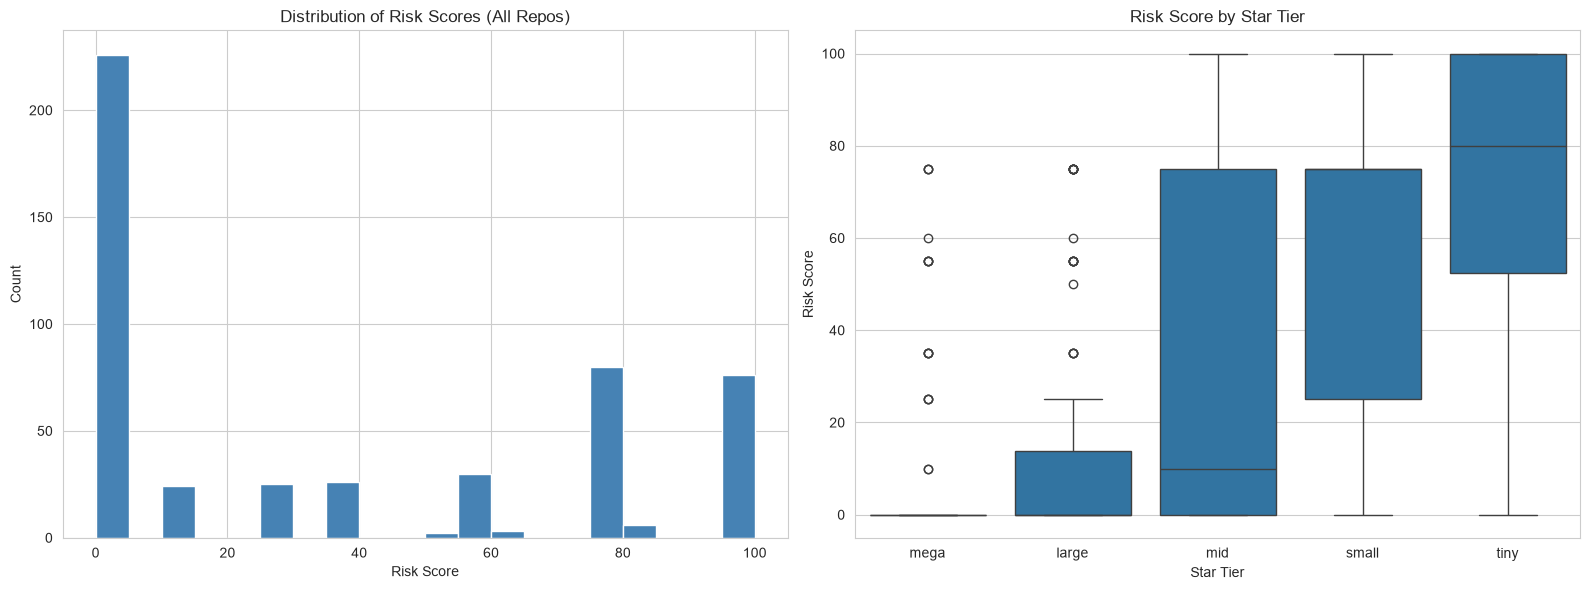

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall risk score distribution
axes[0].hist(df['risk_score'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Risk Scores (All Repos)')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')

# Risk score by star tier, ordered mega -> tiny
tier_order = ['mega', 'large', 'mid', 'small', 'tiny']
sns.boxplot(data=df, x='star_tier', y='risk_score', order=tier_order, ax=axes[1])
axes[1].set_title('Risk Score by Star Tier')
axes[1].set_xlabel('Star Tier')
axes[1].set_ylabel('Risk Score')

plt.tight_layout()
plt.show()

In [7]:
df[(df['star_tier']=='mega') & (df['risk_score'] >= 75)][['repo', 'stars', 'days_since_last_commit', 'is_archived', 'risk_score']]

,repo,stars,days_since_last_commit,is_archived,risk_score
37,CyC2018/CS-Notes,185766,1140.0,False,75
49,AUTOMATIC1111/stable-diffusion-webui,164769,766.0,False,75
51,jlevy/the-art-of-command-line,162214,1147.0,False,75


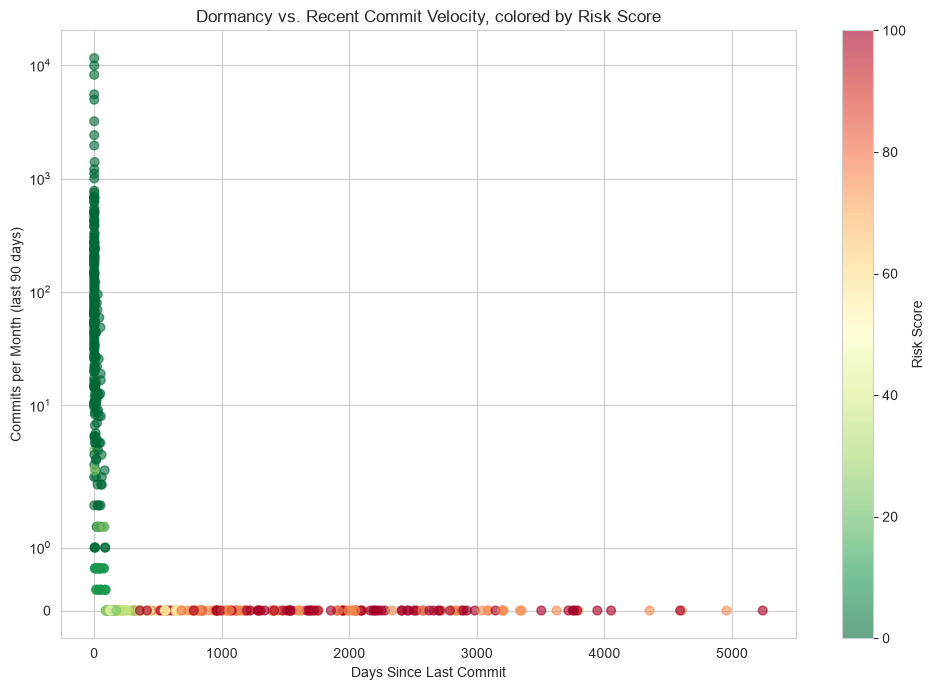

In [8]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['days_since_last_commit'], 
    df['commits_per_month_90d'],
    c=df['risk_score'], 
    cmap='RdYlGn_r',
    alpha=0.6,
    s=40
)
plt.colorbar(scatter, label='Risk Score')
plt.xlabel('Days Since Last Commit')
plt.ylabel('Commits per Month (last 90 days)')
plt.title('Dormancy vs. Recent Commit Velocity, colored by Risk Score')
plt.yscale('symlog')  # commit counts are heavily right-skewed, log scale helps
plt.tight_layout()
plt.show()

#Bucket Order

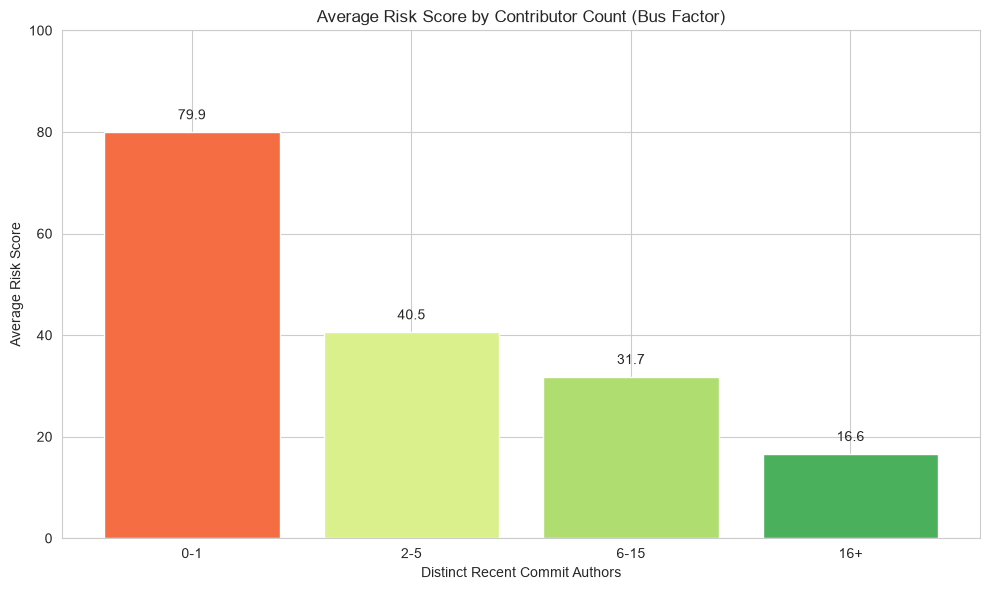

In [12]:
bucket_order = ['0-1', '2-5', '6-15', '16+']
df['contributor_bucket'] = pd.cut(
    df['distinct_recent_commit_authors'],
    bins=[-1, 1, 5, 15, np.inf],
    labels=bucket_order
)

tier_means = df.groupby('contributor_bucket', observed=True)['risk_score'].mean().reindex(bucket_order)

norm = plt.Normalize(0, 100)
colors = plt.cm.RdYlGn_r(norm(tier_means.values))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bucket_order, tier_means.values, color=colors, edgecolor='white')

# add value labels on top of each bar for clarity
for bar, val in zip(bars, tier_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=10)

ax.set_title('Average Risk Score by Contributor Count (Bus Factor)')
ax.set_xlabel('Distinct Recent Commit Authors')
ax.set_ylabel('Average Risk Score')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

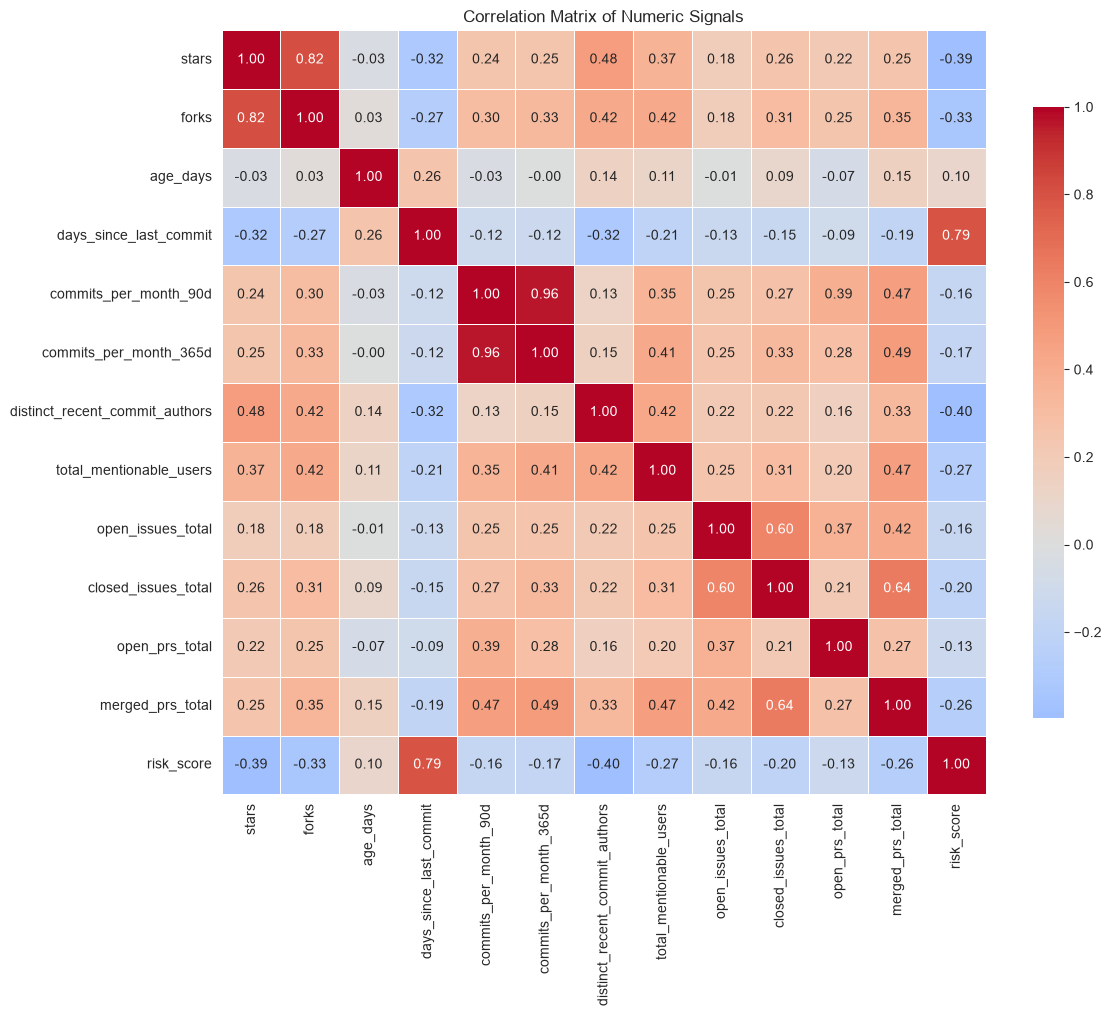

In [13]:
numeric_cols = ['stars', 'forks', 'age_days', 'days_since_last_commit', 
                 'commits_per_month_90d', 'commits_per_month_365d',
                 'distinct_recent_commit_authors', 'total_mentionable_users',
                 'open_issues_total', 'closed_issues_total',
                 'open_prs_total', 'merged_prs_total', 'risk_score']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Signals')
plt.tight_layout()
plt.show()

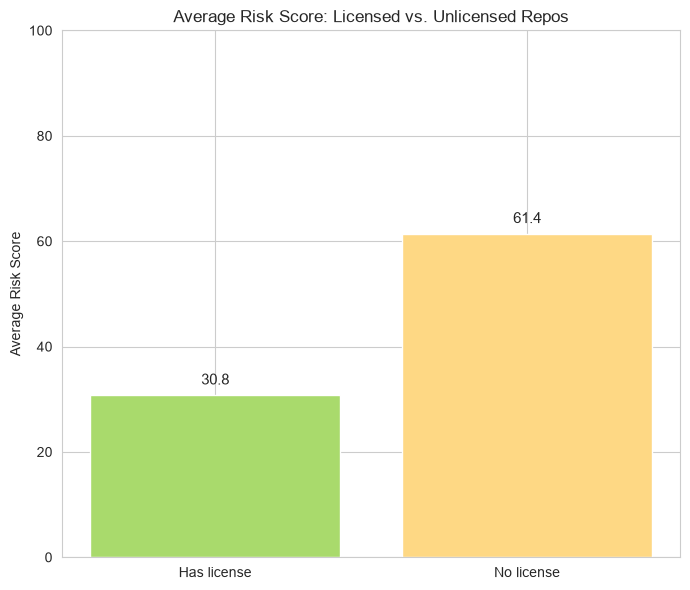

In [14]:
license_summary = df.groupby(df['license'].apply(lambda x: 'No license' if x == 'No license' else 'Has license'))['risk_score'].mean()

plt.figure(figsize=(7, 6))
colors = plt.cm.RdYlGn_r(plt.Normalize(0, 100)(license_summary.values))
bars = plt.bar(license_summary.index, license_summary.values, color=colors, edgecolor='white')
for bar, val in zip(bars, license_summary.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}', ha='center', fontsize=11)
plt.title('Average Risk Score: Licensed vs. Unlicensed Repos')
plt.ylabel('Average Risk Score')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## EDA Summary

Visual analysis confirmed and extended the SQL findings:

- **Risk score distribution is "chunky," not smooth** - a direct consequence 
  of the rule-based scoring formula (discrete point additions), visible 
  clearly in the histogram
- **Star tier shows a clean step-down in risk** from tiny to mega, matching 
  the SQL percentages - but mega-tier still has real outliers 
  (`stable-diffusion-webui`, `CS-Notes`, `the-art-of-command-line`), showing 
  that even massive popularity doesn't guarantee ongoing maintenance
- **Dormancy and commit velocity are mechanically coupled**, not independently 
  informative - a repo either has recent commits (low dormancy) or none 
  (velocity=0), with no smooth middle ground
- **Bus factor confirmed independently**: average risk drops from ~79 
  (0-1 contributors) to ~15 (16+ contributors) - found and fixed a plotting 
  bug where bar colors didn't match actual values before trusting this result
- **Correlation matrix**: `days_since_last_commit` (+0.79) and 
  `distinct_recent_commit_authors` (-0.40) are the strongest correlates, but 
  these were inputs to the score, so this is partially circular. More 
  informative: `stars`/`forks` show only moderate correlation (~-0.35 to 
  -0.39), and **`age_days` is nearly uncorrelated with risk (+0.10)** - an 
  old repo is not inherently more at